# Introduction
As the demand for data professionals has grown rapidly across industries due to organizations' increased reliance on data to make decisions, technical skills, analytical tools, and domain knowledge have become important factors influencing hiring decisions. With that, compensation within the data analytics profession has also become a variabale factor. Understanding which skills are most frequently requested and how those skills relate to salary can provide valuable insight for students, job seekers, and employers alike.

This project analyzes a dataset of approximately 2,000 data analyst job postings from various job sites (e.g. Glassdoor, LinkedIn, ect.). The objective is to identify trends in employer demand, evaluate the relationship between technical skills and compensation, as well as explore how factors such as location, remote work opportunities, and industry influence salary outcomes.

To support this analysis, the raw job posting data was cleaned and transformed into a structured dataset. Salary ranges were converted into numerical variables, company and job title information were standardized, and technical skills were extracted from job descriptions and encoded as binary indicators. This process enabled both descriptive and exploratory analyses of the labor market.

The primary research questions explored in this project are:

Which technical skills are most frequently requested in data analyst job postings?
Which skills are associated with higher salary ranges?
How do salary levels vary across locations and industries?
What are the most common combinations of technical skills sought by employers?

By combining data cleaning, exploratory data analysis, and visualization techniques, this project aims to provide an overview of the data analyst labor market and identify the skills and qualifications most valued by employers.

# Data Source 
Raw data was sourced from a public Kaggle data set posted by Larxel. 

# Data Cleaning and Feature Engineering

## Overview

Before conducting any analysis, the raw job posting data required extensive cleaning and transformation to create a structured dataset usable for statistical analysis and visualization. The original dataset contained salary information stored as text, company names combined with employer ratings, inconsistent location formatting, and unstructured skill descriptions. The primary objective of the data cleaning process was to convert the raw data into a format that would support quantitative analysis while retaining relevant information in each job posting.

## Salary Processing

Salary information was originally stored as text strings of the following salary ranges and supplemental information, such as employer estimates. For example:

* $37K-$57K Glassdoor Est.
* $65K-$95K Employer Provided Salary

To facilitate analysis, salary ranges were separated into three numerical variables:
* Salary_Min: Lower bound of the salary range
* Salary_Max: Upper bound of the salary range
* Salary_Mid: Midpoint of the salary range

midpoint salary calculated as:

* Salary_Mid = (Salary_Min + Salary_Max) / 2

This transformation enabled salary comparisons across skills, industries, and geographic regions.

## Company Name Standardization

Company information frequently contained employer ratings embedded within the same field. For example:

* Visiting Nurse Service of New York 3.8
* Google 4.4
* JPMorgan Chase 4.1

Employer ratings were removed, leaving only the company name. This ensured consistent company identification and prevented employer ratings from interfering with subsequent analyses.

## Job Title Standardization

Job titles often varied despite describing similar positions. Examples included:

* Data Analyst
* Data Analyst I
* Junior Data Analyst
* Associate Data Analyst

Titles were reviewed and standardized where appropriate to reduce redundancy and improve the accuracy of job category comparisons.

## Skill Extraction

One of the most important steps in the project involved extracting technical skills from job descriptions and qualification requirements.

A set of commonly requested analytics skills was identified, including:

* SQL
* Python
* R

Each skill was converted into a binary indicator variable: 1 if the skill was present and 0 if not. 
This structure allows for straightforward analysis of skill demand, skill combinations, and relationships between skills and compensation.

Following the cleaning process, the dataset consisted of structured variables describing:

* Job title
* Company
* City
* State
* Salary Min
* Salary Max
* Salary midpoint
* Technical skills

The resulting dataset provides a foundation for exploratory data analysis, visualization, and statistical investigation of labor market trends within the data analytics profession.


# Load Appropriate Libraries 

In [66]:
import pandas as pd
import numpy as np
import glob 
import matplotlib.pyplot as plt
import seaborn as sns


# Load in Data Set

In [54]:
df = pd.read_csv('DataAnalyst 1(Clean Data).csv').dropna(axis=1, how='all')

In [55]:
df.insert(0, 'Job_ID', range(1, len(df) + 1))

In [56]:
df.head()

,Job_ID,Job Title,Company,City,State,Salary Min,Salary Max,Salary Mid,SQL,Python,R
0,1,"Data Analyst, Center on Immigration and Justic...",Vera Institute of Justice,New York,NY,37000.0,66000.0,51500.0,1.0,1.0,1.0
1,2,Quality Data Analyst,Visiting Nurse Service of New York,New York,NY,37000.0,66000.0,51500.0,1.0,0.0,1.0
2,3,"Senior Data Analyst, Insights & Analytics Team...",Squarespace,New York,NY,37000.0,66000.0,51500.0,1.0,1.0,1.0
3,4,Data Analyst,Celerity,New York,NY,37000.0,66000.0,51500.0,1.0,0.0,1.0
4,5,Reporting Data Analyst,FanDuel,New York,NY,37000.0,66000.0,51500.0,1.0,1.0,1.0


# Exploratory Data Analysis

## Research Question 1: What Skills are most Frequently Requested? 

In [75]:
# Which Skills do companies want the most? 
skill_counts = (
    df[['SQL','Python','R']]
    .sum()
    .reset_index()
)
skill_counts.columns = ['Skill','Count']
skill_counts

,Skill,Count
0,SQL,1389.0
1,Python,637.0
2,R,2252.0


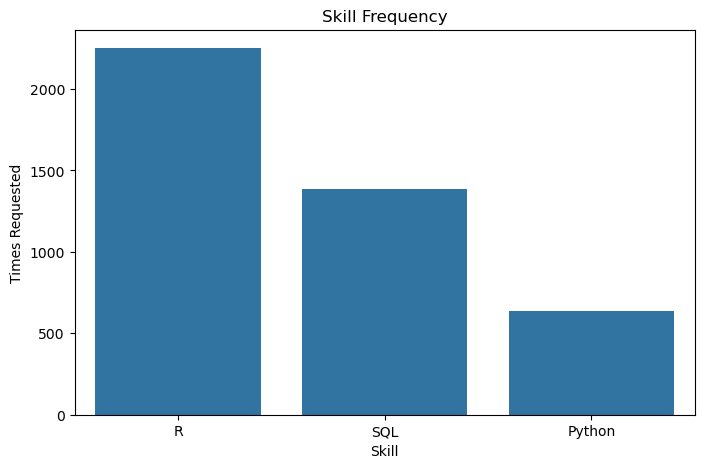

In [80]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=skill_counts.sort_values('Count', ascending=False),
    x='Skill',
    y='Count'
)

plt.title('Skill Frequency')
plt.xlabel('Skill')
plt.ylabel('Times Requested')
plt.show()
plt.clf()

From this chart we see that R is the most requested skill, looking at the number of times it was requested almost every (if not all) of the companies request that you have some knowledge of R. Professionals should 100% make sure they have a strong foundation in R. The next most requested is SQL, and the least requested is Python. This is superising because most postings we see now want some level of Python skills. I would be interested in comparing how much the python skill demand has changed over the past 6 years. 

# Question 2: Which skills are associated with higher salary ranges?

In [73]:
sql_salaries = df.loc[df['SQL'] == 1, 'Salary Mid '].dropna().values
python_salaries = df.loc[df['Python'] == 1, 'Salary Mid '].dropna().values
r_salaries = df.loc[df['R'] == 1, 'Salary Mid '].dropna().values

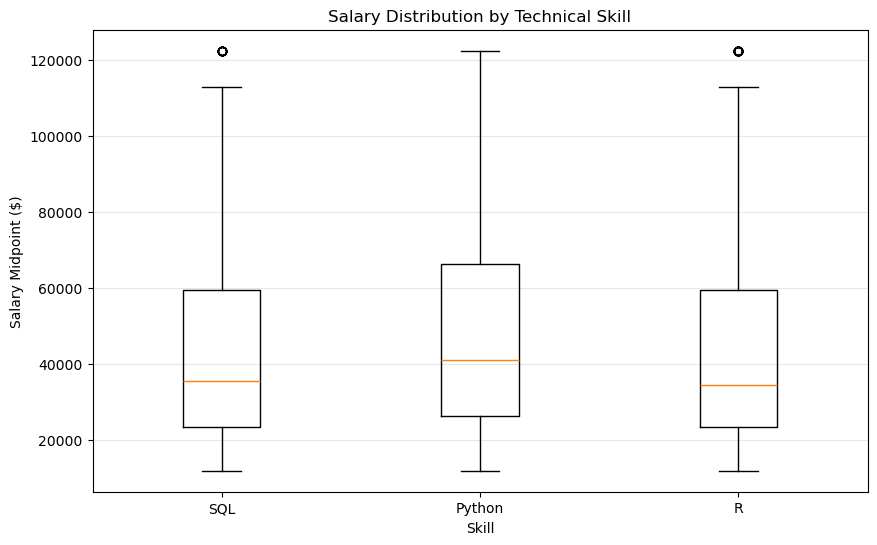

<Figure size 640x480 with 0 Axes>

In [74]:
plt.figure(figsize=(10,6))
plt.boxplot(
    [sql_salaries, python_salaries, r_salaries],
    tick_labels=['SQL', 'Python', 'R']
)

plt.title('Salary Distribution by Technical Skill')
plt.ylabel('Salary Midpoint ($)')
plt.xlabel('Skill')
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.clf()

This histogram describes the distribution in salaries according to the skills they want. Python has the highest median salary but also the most variation. This is interesting because as we saw from the last bar chart, python was the least requested skill. Is this increased salary because there's a lack of professionals that know python while the demand for them is there? R and SQL have about the same median salary but R was requested significantly more then SQL.

# How do salary levels vary across locations and industries?

In [87]:
# What Companies are hiring the most? 
company_counts = (
    df.groupby('Company')
      .size()
      .head(10)
      .reset_index(name='Job_Count')
      .sort_values('Job_Count', ascending=False)
)

company_counts.head(10)

,Company,Job_Count
1176,"Staffigo Technical Services, LLC",58
383,Diverse Lynx,22
756,Lorven Technologies Inc,19
702,Kforce,19
1064,Robert Half,14
821,Mondo,14
135,"Avacend, Inc.",13
1478,eTeam Inc.,10
102,Apple,10
99,Apex Systems,10


## What States are hiring the most Data Analysts? 

In [88]:
state_counts = (
    df.groupby('State ')
      .size()
      .reset_index(name='Job_Count')
      .sort_values('Job_Count', ascending=False)
)

state_counts.head()

,State,Job_Count
2,CA,626
16,TX,394
12,NY,345
7,IL,164
14,PA,114


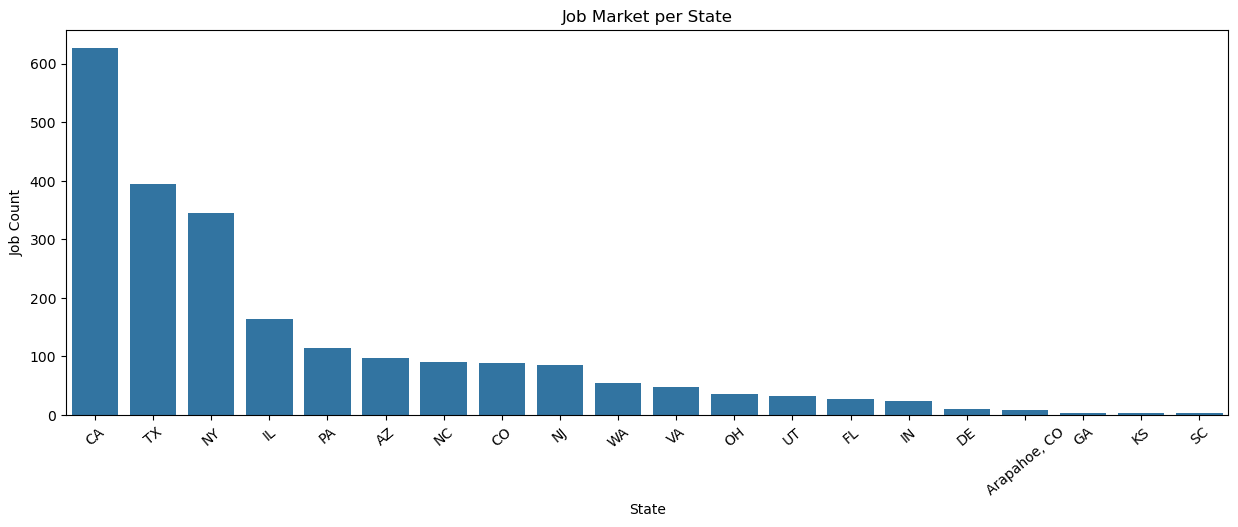

<Figure size 640x480 with 0 Axes>

In [93]:
plt.figure(figsize=(15,5))
sns.barplot(
    data=state_counts.sort_values('Job_Count', ascending=False),
    x='State ',
    y='Job_Count'
)

plt.title('Job Market per State')
plt.xlabel('State')
plt.ylabel('Job Count')
plt.xticks(rotation=40)
plt.show()
plt.clf()

California has the best market for data analyst and South Carolina has the fewest opening positions. As a professional I would research into California and Texas. 

In [102]:
state_salary = (
    df[['State ', 'Salary Mid ']]
    .groupby('State ')
    ['Salary Mid ']
    .mean()
    .reset_index(name='Average Salary')
    .sort_values('Average Salary', ascending=False)
)
state_salary.head()   

,State,Average Salary
7,IL,78310.975610
12,NY,71411.594203
11,NJ,67872.093023
18,VA,65187.500000
2,CA,47465.654952


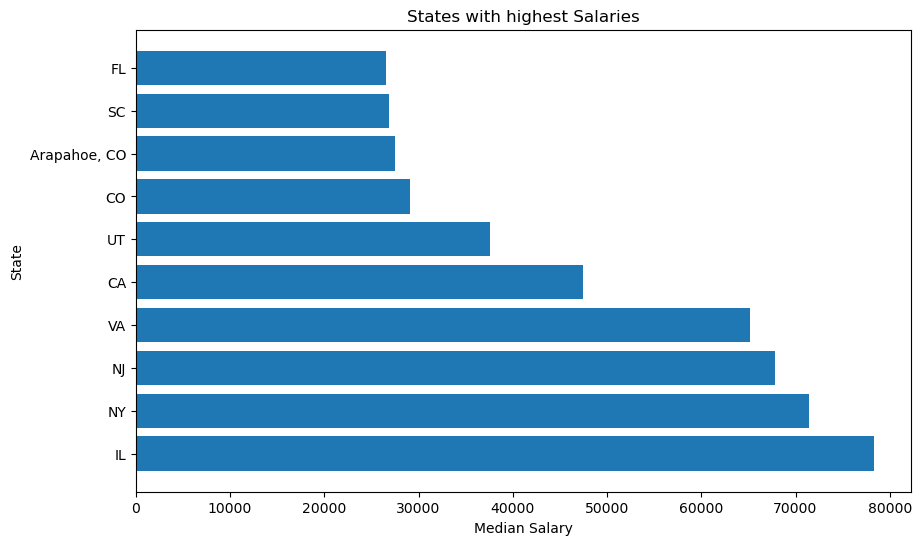

<Figure size 640x480 with 0 Axes>

In [117]:
top_states = top_states = state_salary.head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_states['State '],
    top_states['Average Salary']
)

plt.title('States with highest Salaries')
plt.xlabel('Median Salary')
plt.ylabel('State')
plt.show()
plt.clf()

Illinois has the highest salary median out of all the states, although its 4th in job openings. What you could conclude from this is that due to the higher salary and limited open positions this area is going to be much more competative. Same thing for New York and New Jersey. 

(array([182., 344., 404., 169., 178.,  96.,  53., 152., 129.,  74., 112.,
         74., 105.,  48.,   0.,  14.,  29.,  30.,  30.,  29.]),
 array([ 12000.,  17525.,  23050.,  28575.,  34100.,  39625.,  45150.,
         50675.,  56200.,  61725.,  67250.,  72775.,  78300.,  83825.,
         89350.,  94875., 100400., 105925., 111450., 116975., 122500.]),
 <BarContainer object of 20 artists>)

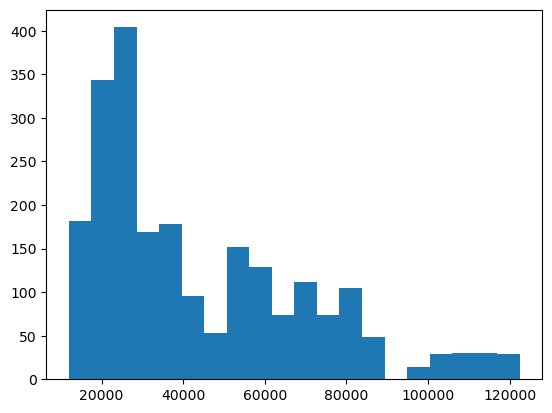

In [118]:
# Distribution of Median Salary over Jobs
plt.hist(df['Salary Mid '], bins=20)

In [ ]:
sns.histplot(population, stat='density')
plt.axvline(pop_mean,color='r',linestyle='dashed')
plt.title(f"Population Mean: {pop_mean}")
plt.xlabel("Weight (lbs)")
plt.show()
plt.clf() # close this plot